# 08 ST-GCN, pixel input: like-for-like comparison with Li et al.

The headline ST-GCN result (notebook 06) uses `body_court` input, chosen in notebook 03 for its own
reasons (removing the camera scale artefact from the drill sessions while keeping court position). That
makes it the right choice for this project's results table, but it is not quite the same setup Li et al.
(2024) themselves used: their ST-GCN sees raw joint coordinates, not a hip centred, body height normalised
representation.

This notebook trains the same tuned recipe (`configs/stgcn_recipe.json`) with **pixel input** instead, so
there is one run in the results that is as close as this project's data and pipeline allow to a direct,
like-for-like replication of their setup. It is not identical (different pose extraction pipeline, our
class balanced sampler, our repaired keypoints), but it isolates the input representation as a variable.

**Scope.** One condition (pixel, advanced augmentation, the tuned recipe), 3 reporting seeds (42, 123, 7).
No tuning, no augmentation-off condition: this run exists purely as a reference point next to the
body_court result, not as a second full model. Test set is evaluated, as this is a final reporting run.
Logs to `BadmintonPoseAnalysis/models/STGCN` alongside the body_court runs, tagged `pixel_variant`.

In [1]:
import os
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from clearml import Task

REPO = os.environ.get("BADMINTON_REPO", "/workspace/badminton-honours-project")
DATA = os.environ.get("BADMINTON_DATA", "/workspace/data")
sys.path.insert(0, REPO)
import dataset as ds
from models import stgcn as stgcn_model
import training as tr

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.__version__, device, torch.cuda.get_device_name(0) if device.type == "cuda" else "")
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.spines.top": False, "axes.spines.right": False})

2.1.0+cu118 cuda NVIDIA GeForce RTX 4090


In [2]:
PROJECT = "BadmintonPoseAnalysis/models/STGCN"
KEYPOINTS = f"{DATA}/keypoints_interp"
OUT = os.environ.get("BADMINTON_OUTPUTS", "/workspace/outputs") + "/models/stgcn_pixel"
os.makedirs(OUT, exist_ok=True)

SEEDS = [42, 123, 7]
SPLITS = ("train", "val", "test")   # final reporting run: test is evaluated
NORMALISATION, USE_COURT = "pixel", False
NUM_WORKERS, EVAL_WORKERS = 20, 8

with open(f"{REPO}/configs/stgcn_recipe.json") as f:
    RECIPE = json.load(f)
print("using recipe:", RECIPE)

LI_ET_AL_STGCN = {"top1": 0.7441, "top5": 0.9376, "mca": 0.6144}
# from the body_court final run (notebook 06), for the comparison table below
BODY_COURT_FINAL = {"top1": 0.7229, "top1_std": 0.0106, "top5": 0.9437, "mca": 0.6121, "mca_std": 0.0133}

using recipe: {'model': 'ST-GCN', 'normalisation': 'body_court', 'selected': 'combination', 'changes_from_baseline': {'weight_decay': 0.005, 'target_per_class': 300}, 'augmentation': 'advanced', 'min_native_frames': 5, 'batch_size': 16, 'lr': 0.01, 'momentum': 0.9, 'gamma': 0.1, 'select_metric': 'top1', 'weight_decay': 0.005, 'label_smoothing': 0.0, 'schedule': 'step10', 'target_per_class': 300, 'num_epochs': 60, 'patience': 20, 'tuning': {'seeds': [11, 22], 'val_top1': 0.7612, 'baseline_val_top1': 0.7394}}


In [3]:
manifest = ds.load_filtered_manifest(f"{DATA}/split_manifest.csv", f"{DATA}/extraction_log.csv",
                                     f"{DATA}/keypoints_interp_log.csv", RECIPE["min_native_frames"])
class_names = sorted(manifest["class_name"].unique())
class_to_id = {c: i for i, c in enumerate(class_names)}
split_hash = open(f"{DATA}/split_manifest.sha256").read().split()[0]
forward = stgcn_model.make_forward(USE_COURT)
in_channels = 7 if USE_COURT else 5

manual review: dropped 4 clips
short clip rule: dropped 4 train clips with fewer than 5 real frames
7810 clips remain (train 6247, test 782, val 781)


## Smoke test

Run alone first: confirms the pixel condition actually produces pixel scale coordinates (not accidentally
still normalised) and that the 5 channel model builds and trains one step cleanly.

In [4]:
tr.seed_everything(0)
loaders = tr.build_loaders(manifest, KEYPOINTS, class_to_id, RECIPE["augmentation"], NORMALISATION, seed=0,
                           batch_size=RECIPE["batch_size"], target_per_class=300, num_workers=2, eval_workers=2)
model = stgcn_model.build_stgcn(in_channels, len(class_names)).to(device)
batch = next(iter(loaders["train"]))
xy = batch["keypoints"][..., :2]
print(f"channels {in_channels}, xy range [{xy.min():.1f}, {xy.max():.1f}] (should be in the hundreds, not ~[-2, 2])")
assert xy.abs().max() > 10, "input does not look like pixel coordinates"

logits = forward(model, batch, device)
assert logits.shape == (RECIPE["batch_size"], len(class_names))
nn.CrossEntropyLoss()(logits, batch["label"].to(device)).backward()
assert not [n for n, p in model.named_parameters() if p.requires_grad and p.grad is None]
del model, loaders
print("smoke test passed")

channels 5, xy range [288.6, 921.8] (should be in the hundreds, not ~[-2, 2])
smoke test passed


## Runs

Three seeds, same recipe as the body_court final result. Results are appended after each run so the cell
can be safely re-run if interrupted.

In [5]:
results_path = f"{OUT}/results.csv"
done = pd.read_csv(results_path) if os.path.exists(results_path) else pd.DataFrame(columns=["seed"])

for seed in SEEDS:
    if (done["seed"] == seed).any():
        print(f"skip seed {seed}, already done")
        continue
    run_name = f"stgcn_pixel_s{seed}"
    print(f"\n=== {run_name} ===")
    tr.seed_everything(seed)

    task = Task.init(project_name=PROJECT, task_name=run_name, task_type=Task.TaskTypes.training,
                     tags=["pixel_variant", "stgcn", f"seed{seed}"], reuse_last_task_id=False,
                     auto_connect_frameworks={"matplotlib": False, "pytorch": False})
    task.connect({**RECIPE, "normalisation": NORMALISATION, "in_channels": in_channels, "seed": seed,
                  "keypoints": KEYPOINTS, "split_sha256": split_hash, "purpose": "like-for-like vs Li et al."})

    loaders = tr.build_loaders(manifest, KEYPOINTS, class_to_id, RECIPE["augmentation"], NORMALISATION, seed=seed,
                               batch_size=RECIPE["batch_size"], target_per_class=RECIPE["target_per_class"],
                               num_workers=NUM_WORKERS, eval_workers=EVAL_WORKERS)
    model = stgcn_model.build_stgcn(in_channels, len(class_names)).to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=RECIPE["lr"], momentum=RECIPE["momentum"],
                                weight_decay=RECIPE["weight_decay"])
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=RECIPE["gamma"])
    criterion = nn.CrossEntropyLoss(label_smoothing=RECIPE["label_smoothing"])

    _, history, best_epoch = tr.train_model(model, forward, loaders, optimizer, scheduler, criterion, device,
                                            task.get_logger(), num_epochs=RECIPE["num_epochs"],
                                            patience=RECIPE.get("patience", 20), select_metric=RECIPE["select_metric"],
                                            splits=SPLITS)
    metrics = tr.report_run(task, model, forward, loaders, class_names, device, history, best_epoch,
                            out_dir=f"{OUT}/{run_name}", run_name=run_name, splits=SPLITS, show=False,
                            extra={"seed": seed, "normalisation": NORMALISATION})
    task.close()

    done = pd.concat([done, pd.DataFrame([metrics])], ignore_index=True)
    done.to_csv(results_path, index=False)
    del model, loaders
    torch.cuda.empty_cache()

skip seed 42, already done
skip seed 123, already done
skip seed 7, already done


## Comparison

In [6]:
results = pd.read_csv(results_path)
summary = Task.init(project_name=PROJECT, task_name="pixel_vs_body_court_comparison", task_type=Task.TaskTypes.qc,
                    tags=["pixel_variant", "summary"], reuse_last_task_id=False, auto_connect_frameworks={"matplotlib": False})
slog = summary.get_logger()

row = {
    "condition": "pixel (this run)", "top1": results["test_top1"].mean(), "top1_std": results["test_top1"].std(),
    "top5": results["test_top5"].mean(), "mca": results["test_mca"].mean(), "mca_std": results["test_mca"].std(),
}
table = pd.DataFrame([
    row,
    {"condition": "body_court (headline result)", "top1": BODY_COURT_FINAL["top1"], "top1_std": BODY_COURT_FINAL["top1_std"],
     "top5": BODY_COURT_FINAL["top5"], "mca": BODY_COURT_FINAL["mca"], "mca_std": BODY_COURT_FINAL["mca_std"]},
    {"condition": "Li et al. (2024)", "top1": LI_ET_AL_STGCN["top1"], "top1_std": np.nan,
     "top5": LI_ET_AL_STGCN["top5"], "mca": LI_ET_AL_STGCN["mca"], "mca_std": np.nan},
])
for c in ["top1", "top1_std", "top5", "mca", "mca_std"]:
    table[c] = (100 * table[c]).round(2)
slog.report_table("pixel vs body_court vs Li et al.", "test", iteration=0, table_plot=table)
summary.upload_artifact("results", artifact_object=results_path)
table

ClearML Task: created new task id=41914cc43a944e1b97fc29f520bc70da
2026-09-30 12:02:42,045 - clearml.Repository Detection - WARNING - Failed accessing the jupyter server(s): []
ClearML results page: https://app.clear.ml/projects/23df26f6d3e54aa9a4edc4761cccc6b1/tasks/41914cc43a944e1b97fc29f520bc70da/output/log


,condition,top1,top1_std,top5,mca,mca_std
0,pixel (this run),72.59,1.22,94.84,61.51,2.43
1,body_court (headline result),72.29,1.06,94.37,61.21,1.33
2,Li et al. (2024),74.41,NaN,93.76,61.44,NaN


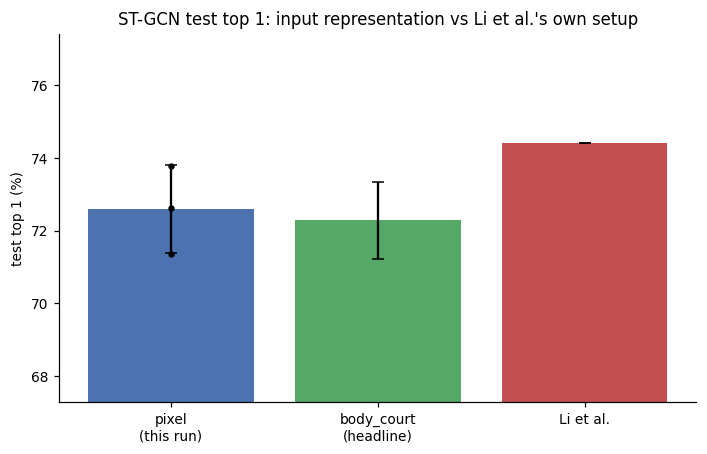

In [7]:
fig, ax = plt.subplots(figsize=(6.5, 4.2))
x = np.arange(3)
labels = ["pixel\n(this run)", "body_court\n(headline)", "Li et al."]
tops = [row["top1"], BODY_COURT_FINAL["top1"], LI_ET_AL_STGCN["top1"]]
errs = [results["test_top1"].std(), BODY_COURT_FINAL["top1_std"], 0]
ax.bar(x, [100 * t for t in tops], yerr=[100 * e for e in errs], capsize=4,
      color=["#4c72b0", "#55a868", "#c44e52"])
ax.scatter(np.zeros(len(SEEDS)), 100 * results["test_top1"], color="black", s=10, zorder=3)
ax.set_xticks(x, labels)
ax.set_ylabel("test top 1 (%)")
ax.set_ylim(min(100 * t for t in tops) - 5, max(100 * t for t in tops) + 3)
ax.set_title("ST-GCN test top 1: input representation vs Li et al.'s own setup")
fig.tight_layout()
slog.report_matplotlib_figure("pixel vs body_court vs Li et al.", "test", figure=fig, iteration=0, report_interactive=False)
plt.show()
summary.close()

## Reading the result

- If pixel closes some or all of the gap to Li et al., that supports the idea that `body_court`'s MCA
  benefit comes at some cost to top 1, consistent with what the normalisation experiment (notebook 03)
  already suggested on a smaller drill vs match comparison.
- If pixel does not close the gap either, that points more strongly at pipeline level differences (pose
  extraction, the class balanced sampler) rather than input representation as the explanation, and is worth
  stating plainly in the thesis discussion rather than left unexplained.
- Either way, `body_court` remains the input used for every model in the main results table; this run exists
  only to give the discussion section a concrete, like-for-like reference point.